# Sun-Blocking sanity-check walkthrough

The bandit is rewarded for occluding the guard's view of the Sun. The reward is built around two factors: an *angular factor* `-û_BG·û_BS` (the bandit interposes when this is positive — sun and guard are on opposite sides of the bandit) and a *range factor* `exp(-decay·(d - d_target)²)` that places a vertex at the bandit and forms peak/trough lobes at `target_viewing_distance_m`. The full reward is the product, so the bandit gets a positive lobe when interposing at the right range and a negative lobe when the geometry is reversed (guard between bandit and sun). This formulation mirrors the [KSP-DG SB1 reference](https://github.com/mit-ll/spacegym-kspdg/blob/main/src/kspdg/sb1/sb1_base.py).

This notebook builds the scenario, runs a rollout, renders the trajectory, plots the rollout-time diagnostic, and renders the 2D bandit-position reward surface.

For framework deep-dive see `examples/workflow_3d_rtn.ipynb`. For the reward formula and knob reference see `docs/games/sun-blocking.md`.

In [1]:
%load_ext autoreload
%autoreload 2

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from orbital_game import OrbitalGameEnv, rollout
from orbital_game.env.types import BySide
from orbital_game.games import make_sun_blocking
from orbital_game.policies.library import ZeroControl
from orbital_game.viz import (
    plot_reward_diagnostic,
    plot_reward_position_sweep,
    plot_rollout_panels,
    plot_rollout_rewards,
    plot_sun_blocking_animated_diagnostic,
    plot_sun_blocking_diagnostic,
    plot_sun_blocking_position_sweep,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Build the scenario

`make_sun_blocking` takes two game-specific knobs (`target_viewing_distance_m`, `range_decay_coef`) plus the standard scenario knobs. The project-default IC sampler places the bandit far from `d_target`, so we override the bandit IC locally with `dataclasses.replace` to put the rollout inside the high-reward region.

In [2]:
cfg = make_sun_blocking(
    target_viewing_distance_m=500.0,
    range_decay_coef=4.0e-6,
    n_guards=1, n_bandits=1,
    dt=10.0, max_horizon_s=5400.0, seed=0,
)

# Override bandit IC locally so the rollout visits the high-reward region.
# (Project-default IC has the bandit too far from d_target.)
from dataclasses import replace
from orbital_game.sampling.side import RelativeEllipse
from orbital_game.sampling.spec import ICSpec

cfg = replace(
    cfg,
    ic_sampler=ICSpec(
        guard_sampler=RelativeEllipse(
            radial_ellipse_m=500.0, phase_rad=0.0, sigma_radial_ellipse_m=10.0,
        ),
        bandit_sampler=RelativeEllipse(
            radial_ellipse_m=600.0, phase_rad=jnp.pi / 4.0, sigma_radial_ellipse_m=10.0,
        ),
        validators=(),
        max_attempts=100,
    ),
)

print(f"max_steps:                  {cfg.max_steps}")
print(f"target_viewing_distance_m:  {cfg.game.target_viewing_distance_m} m")
print(f"range_decay_coef:           {cfg.game.range_decay_coef}")
print(f"reference orbit:            {cfg.reference_orbit.position_eci[:3]} m")

max_steps:                  540
target_viewing_distance_m:  500.0 m
range_decay_coef:           4e-06
reference orbit:            [7000000.       0.       0.] m


## 2. Construct env and run two rollouts (zero-control, two seeds)

In [3]:
env = OrbitalGameEnv(cfg)
guard_policy = ZeroControl(n_vehicles=cfg.n_guards, action_dim=3)
bandit_policy = ZeroControl(n_vehicles=cfg.n_bandits, action_dim=3)
init_ps = BySide(
    guard=lambda c, s, k: None,
    bandit=lambda c, s, k: None,
)
key1, key2 = jax.random.split(jax.random.PRNGKey(42), 2)
traj1 = rollout(env, BySide(guard=guard_policy, bandit=bandit_policy), init_ps, key1, n_steps=cfg.max_steps)
traj2 = rollout(env, BySide(guard=guard_policy, bandit=bandit_policy), init_ps, key2, n_steps=cfg.max_steps)
print(f"rollout 1 bandit return:  {float(traj1.sides.bandit.reward.sum()):.4f}")
print(f"rollout 2 bandit return:  {float(traj2.sides.bandit.reward.sum()):.4f}")

rollout 1 bandit return:  -344.6295
rollout 2 bandit return:  -334.7949


## 3. Trajectory + reward over time

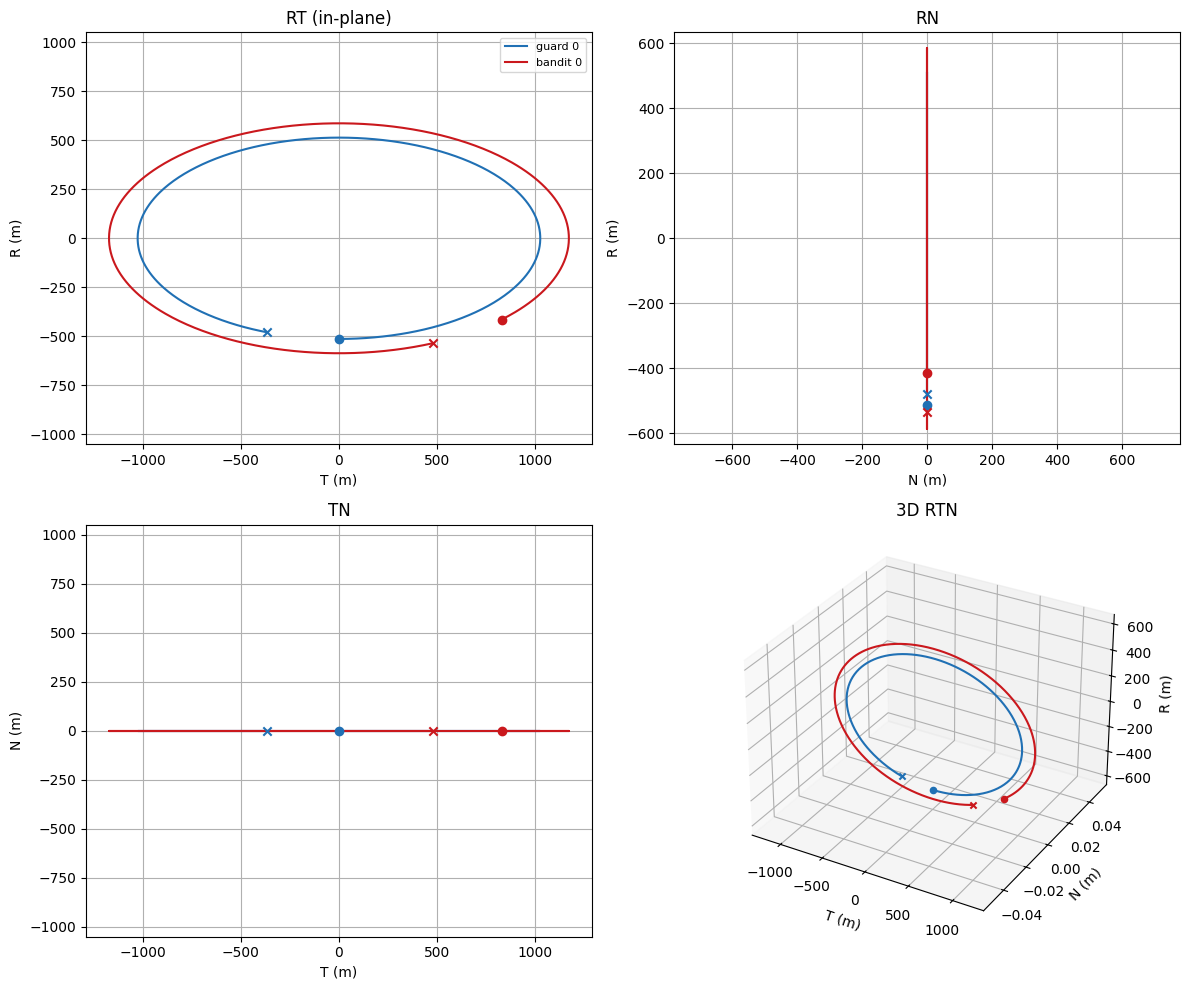

In [4]:
fig = plot_rollout_panels(traj1)
plt.show()

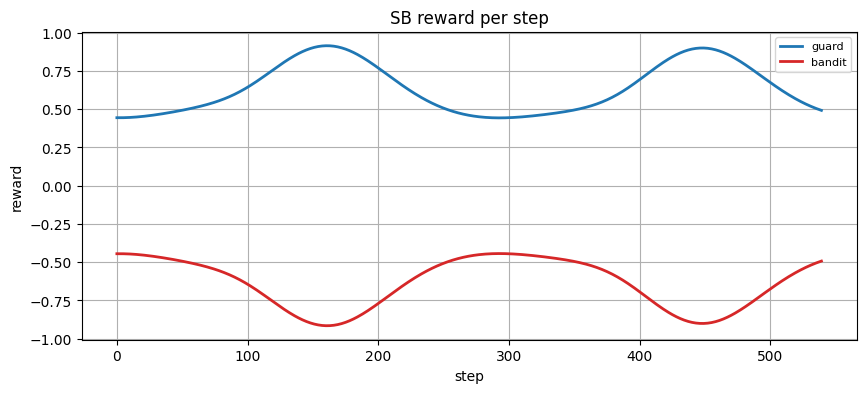

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_rollout_rewards(traj1, ax=ax)
ax.set_title("SB reward per step")
plt.show()

## 4. Game-specific rollout diagnostic

Three panels: `-û_BG·û_BS` (the angular factor), `|bandit − guard|` with `target_viewing_distance_m` marked, and the recorded rewards with the formula reconstruction overlaid in dotted black. The reconstruction should sit exactly on top of the recorded bandit reward — that's the verification that the implementation matches the formula.

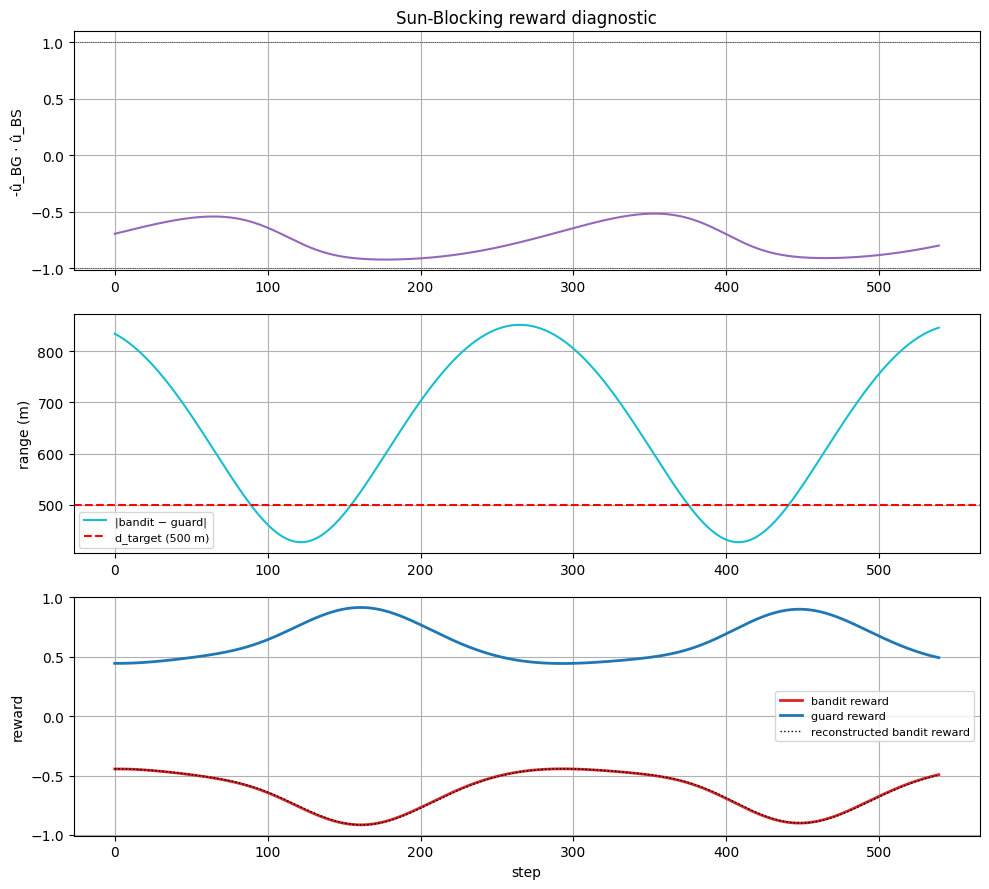

In [6]:
fig = plot_sun_blocking_diagnostic(traj1, cfg)
plt.show()

## Animated diagnostic

Side-by-side animation: the 3D RTN scene with the sun-direction vector emanating from the guard (gold star at `target_viewing_distance_m`) on the left, and the cumulative reward over time with a moving cursor on the right. Watch the bandit drift through the peak/trough lobes and confirm the cumulative reward responds.

In [ ]:
from IPython.display import HTML
import shutil
import pathlib

fig_anim, anim = plot_sun_blocking_animated_diagnostic(traj1, cfg, fps=15, n_frames=120)

# If ffmpeg is available, also save to MP4 in the repo's outputs/ directory.
def _repo_root() -> pathlib.Path:
    here = pathlib.Path.cwd().resolve()
    for parent in (here, *here.parents):
        if (parent / "pyproject.toml").exists():
            return parent
    return here

if shutil.which("ffmpeg") is not None:
    out_dir = _repo_root() / "outputs"
    out_dir.mkdir(exist_ok=True)
    out_path = out_dir / "sb_animated_diagnostic.mp4"
    anim.save(str(out_path), fps=15)
    print(f"saved {out_path}  ({out_path.stat().st_size:,} bytes)")
else:
    print("ffmpeg not available — skipping MP4 export")

# Display inline in the notebook (works in Jupyter/Lab; needs a recent matplotlib).
HTML(anim.to_jshtml(default_mode='loop'))

## 5. 2D position-sweep surface

Bandit-position sweep with guard fixed at the reference origin and sun direction at `t=0`. Surface should show a positive lobe (bandit interposing) and a negative lobe (guard interposing) straddling the guard along the projected sun direction. **This shape mirrors the [KSP-DG SB1](https://github.com/mit-ll/spacegym-kspdg/blob/main/src/kspdg/sb1/sb1_base.py) reference.**

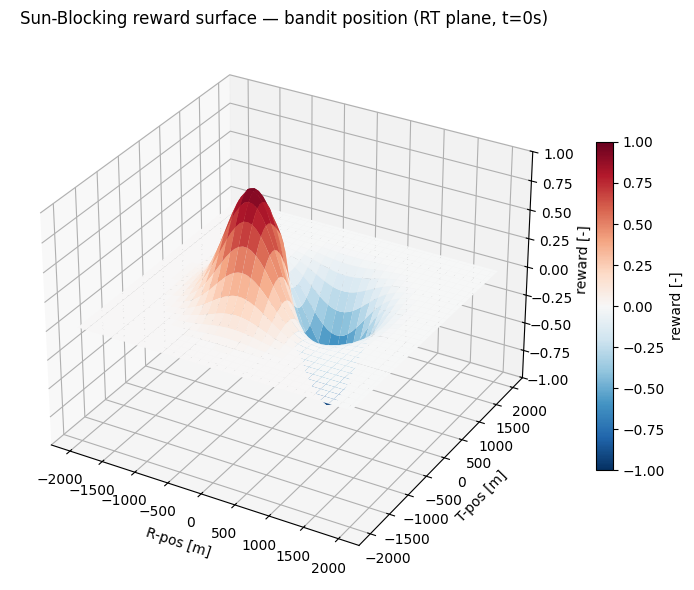

In [7]:
fig = plot_sun_blocking_position_sweep(cfg, grid_extent_m=2000.0, grid_steps=64, axis_pair="rt")
plt.show()

## 6. Where to next

- Framework deep-dive: `examples/workflow_3d_rtn.ipynb`
- Game guide: `docs/games/sun-blocking.md`
- Other games: `examples/games/lady_bandit_guard.ipynb`, `pursuit_evasion.ipynb`, `observation_blocking.ipynb`